# 04 - Advanced Methods

Three methods beyond the meta-learner / DML / forest core: DragonNet (causalml, neural), a DR-AIPW ATE with a confidence interval (causalml), and instrumental variables via DMLIV (econml).

Criteo has two treatment columns:

```
Z = treatment  (ad OFFERED - randomized)
T = exposure   (ad actually VIEWED - endogenous; user decides whether to view)
Y = conversion
```

Notebooks 01-03 estimate the Intent-to-Treat (ITT) effect of the offer $Z$ - the right quantity for budget and policy decisions. DMLIV instead uses $Z$ as an instrument for exposure $T$ to estimate the Local Average Treatment Effect (LATE).

## Setup

In [1]:
ARTIFACT_NAME = '04_advanced'
import time, warnings, pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from criteo_data import fetch_criteo
from sklift.metrics import uplift_auc_score, qini_auc_score, uplift_at_k

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

SEED = 42
np.random.seed(SEED)
SAMPLE_SIZE = 500_000

print('Loading Criteo...')
ds = fetch_criteo(target_col='conversion')
X_full, y_full, treat_full = ds.data, ds.target, ds.treatment
if SAMPLE_SIZE and SAMPLE_SIZE < len(X_full):
    idx = np.random.choice(len(X_full), SAMPLE_SIZE, replace=False)
    X_full = X_full.iloc[idx].reset_index(drop=True)
    y_full = y_full.iloc[idx].reset_index(drop=True)
    treat_full = treat_full.iloc[idx].reset_index(drop=True)

strat = treat_full.values * 2 + y_full.values
X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X_full.values, y_full.values, treat_full.values,
    test_size=0.2, random_state=SEED, stratify=strat,
)
print(f'Train: {len(X_train):,}  Test: {len(X_test):,}')

results = {}
qini_curves = {}

def evaluate(name, scores, elapsed):
    s = np.asarray(scores).flatten()
    row = {
        'AUUC':       round(uplift_auc_score(y_test, s, t_test), 6),
        'Qini':       round(qini_auc_score(y_test, s, t_test),   6),
        'Uplift@10%': round(uplift_at_k(y_test, s, t_test, strategy='by_group', k=0.1), 4),
        'Uplift@20%': round(uplift_at_k(y_test, s, t_test, strategy='by_group', k=0.2), 4),
        'Time(s)':    round(elapsed, 1),
    }
    results[name] = row
    qini_curves[name] = s
    print(f'[{name:<28}]  Qini={row["Qini"]:.6f}  @10%={row["Uplift@10%"]:.4f}  @20%={row["Uplift@20%"]:.4f}  time={row["Time(s)"]}s')
    return row


Loading Criteo...


Train: 400,000  Test: 100,000


## 1. DragonNet

Shi, Blei & Veitch, Adapting Neural Networks for the Estimation of Treatment Effects, NeurIPS 2019: a shared representation with per-arm outcome heads and a propensity head, plus a targeted-regularization term tied to the TMLE ATE-targeting equation. On tabular data with strong gradient-boosting baselines, neural methods often do not win. Requires TensorFlow; if `causalml.inference.tf` fails to import, the section is skipped.

In [2]:
try:
    from causalml.inference.tf import DragonNet
    DRAGONNET_OK = True
except ImportError as e:
    print(f'DragonNet unavailable ({e}); skipping. Install: pip install causalml[tf]')
    DRAGONNET_OK = False

DragonNet unavailable (No module named 'tensorflow'); skipping. Install: pip install causalml[tf]


In [3]:
if DRAGONNET_OK:
    from sklearn.preprocessing import StandardScaler
    t0 = time.time()
    # DragonNet is a neural net and does not standardize internally; scale the
    # (unscaled) Criteo features so the shared representation trains sensibly.
    scaler = StandardScaler().fit(X_train)
    dn = DragonNet(neurons_per_layer=200, targeted_reg=True, verbose=0)
    dn.fit(scaler.transform(X_train), t_train, y_train)
    pred = dn.predict_tau(scaler.transform(X_test))   # per-sample CATE estimate
    tau = pred.flatten() if pred.ndim > 1 else pred
    evaluate('DragonNet', tau, time.time() - t0)
else:
    print('Skipped DragonNet.')

Skipped DragonNet.


## 2. ATE with a confidence interval (DR-AIPW)

We compute the plain AIPW / DR ATE, not TMLE: the efficient influence function is averaged directly, with no targeting step. Asymptotically AIPW and TMLE share the same efficient influence curve and variance; they differ only in finite samples. That is why the leaderboard row below is labelled `DR-Learner (AIPW)`, not "TMLE". Cross-fit $\hat m_0, \hat m_1, \hat e$ (propensity clipped to [0.01, 0.99]), then for each $i$:

$$
\psi_i \;=\; \hat m_1(X_i) - \hat m_0(X_i)
   + \frac{T_i}{\hat e(X_i)}(Y_i - \hat m_1(X_i))
   - \frac{1 - T_i}{1 - \hat e(X_i)}(Y_i - \hat m_0(X_i)).
$$

The ATE estimate is $\hat\tau = \frac1n \sum_i \psi_i$, with asymptotic variance $\mathrm{Var}(\psi)/n$; we compute it directly so the reported number matches this formula (a library ATE helper would return the mean of a fitted CATE model, a different quantity). On this run: DR-AIPW ATE 0.000461, 95% CI [-0.000184, 0.001107], vs diff-in-means 0.001253 - both estimate the same ATE, and the gap is finite-sample noise on a ~0.3% outcome. For the leaderboard row we pass the known constant RCT propensity to `BaseDRLearner`, so the second stage is not distorted by a propensity fitted on the 85/15 skew.

In [4]:
from causalml.inference.meta import BaseDRLearner
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.model_selection import StratifiedKFold

# ATE via the DR-AIPW influence function defined above. Cross-fit the nuisances
# out-of-fold, clip the propensity to the project's [0.01, 0.99], then average
# psi; Var(psi)/n gives the CI. We compute this directly so the number matches
# the formula exactly (a library ATE helper would report the mean of a fitted
# CATE model instead, which is a different quantity).
def aipw_ate(X, T, Y, n_splits=5, clip=(0.01, 0.99), seed=SEED):
    n = len(X); m0 = np.zeros(n); m1 = np.zeros(n); e = np.zeros(n)
    lp = dict(n_estimators=300, learning_rate=0.05, max_depth=6, num_leaves=63,
              min_child_samples=50, random_state=seed, n_jobs=-1, verbose=-1)
    for tr, te in StratifiedKFold(n_splits, shuffle=True, random_state=seed).split(X, T * 2 + Y):
        e[te]  = LGBMClassifier(**lp).fit(X[tr], T[tr]).predict_proba(X[te])[:, 1]
        m0[te] = LGBMClassifier(**lp).fit(X[tr][T[tr] == 0], Y[tr][T[tr] == 0]).predict_proba(X[te])[:, 1]
        m1[te] = LGBMClassifier(**lp).fit(X[tr][T[tr] == 1], Y[tr][T[tr] == 1]).predict_proba(X[te])[:, 1]
    e = np.clip(e, *clip)
    return (m1 - m0) + T * (Y - m1) / e - (1 - T) * (Y - m0) / (1 - e)

t0 = time.time()
psi = aipw_ate(X_train, t_train, y_train)
ate = float(psi.mean()); se = float(psi.std(ddof=1) / np.sqrt(len(psi)))
dim = float(y_train[t_train == 1].mean() - y_train[t_train == 0].mean())
print(f'DR-AIPW ATE: {ate:.6f}  CI95=[{ate - 1.96 * se:.6f}, {ate + 1.96 * se:.6f}]')
print(f'Diff-in-means (RCT sanity check): {dim:.6f}')
print('(both estimate the same ATE; the small gap is finite-sample noise on a ~0.3% outcome)')

# Leaderboard row: a DR-Learner CATE, ranked by Qini on the hold-out. We pass the
# known constant RCT propensity (and a seed) so the second stage is not distorted
# by a propensity fitted on the 85/15 skew, which otherwise inflates tau tails.
dr = BaseDRLearner(
    learner=LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                          num_leaves=63, random_state=SEED, n_jobs=-1, verbose=-1),
)
dr.fit(X=X_train, treatment=t_train, y=y_train,
       p=np.full(len(y_train), t_train.mean()), seed=SEED)
tau = dr.predict(X=X_test).flatten()
evaluate('DR-Learner (AIPW)', tau, time.time() - t0)

DR-AIPW ATE: 0.000461  CI95=[-0.000184, 0.001107]
Diff-in-means (RCT sanity check): 0.001253
(both estimate the same ATE; the small gap is finite-sample noise on a ~0.3% outcome)


[DR-Learner (AIPW)           ]  Qini=0.103908  @10%=0.0093  @20%=0.0051  time=77.2s


{'AUUC': 0.003486,
 'Qini': 0.103908,
 'Uplift@10%': 0.0093,
 'Uplift@20%': 0.0051,
 'Time(s)': 77.2}

## 3. Instrumental Variables - LATE via DMLIV

$Z$ = offer (randomized), $T$ = exposure (endogenous: users who choose to view the ad are not a random subsample), $Y$ = conversion. Compliance is one-sided ($T_i = 1 \Rightarrow Z_i = 1$), so the Imbens-Angrist (1994) conditions are unusually clean here: the instrument is randomized by design, relevance and monotonicity hold automatically because $\Pr(T=1 \mid Z=0) = 0$, and exclusion assumes an offered-but-unviewed ad does not change behavior. The IV estimand is the LATE:

$$
\mathrm{LATE} \;=\; \mathbb{E}[Y(T=1) - Y(T=0) \mid \text{complier}] \;=\; \frac{\mathrm{ITT}_Y}{\mathrm{ITT}_T}.
$$

Under Criteo's one-sided non-compliance, $\mathrm{ITT}_T = \Pr(T=1 \mid Z=1)$ - the take-up rate of the offer. DMLIV (Syrgkanis, Lei, Oprescu, Hei, Battocchi & Lewis, NeurIPS 2019) estimates a CATE-on-compliers with cross-fitted ML nuisances. Loading note: `fetch_criteo` returns the offer and exposure indicators together only with `treatment_col='all'`; if the `exposure` column is missing, DMLIV is skipped.

In [5]:
# Load a second view of the dataset that exposes BOTH treatment columns.
# fetch_criteo puts only the 12 features in .data; the offer/exposure indicators
# are returned in .treatment when treatment_col='all'.
ds_iv = fetch_criteo(target_col='conversion', treatment_col='all')
print('IV treatment columns:', list(ds_iv.treatment.columns))
HAS_EXPOSURE = 'exposure' in ds_iv.treatment.columns
print(f'HAS_EXPOSURE = {HAS_EXPOSURE}')

IV treatment columns: ['exposure', 'treatment']
HAS_EXPOSURE = True


The reported LATE is several times larger than the ITT seen elsewhere, because LATE conditions on compliers - users who view the ad only when offered - a much smaller group than everyone offered:

$$
\underbrace{\mathrm{ITT}}_{\text{averaged over all offered}} \;=\; \underbrace{\Pr(\text{complier})}_{\text{ad take-up}} \times \underbrace{\mathrm{LATE}}_{\text{effect on compliers}}
$$

On this sample the ITT is about 0.00125 and ad take-up about 0.036, so the Wald LATE is roughly $0.00125 / 0.036 \approx 0.035$ - matching the DMLIV estimate below. The two answer different questions: ITT for "should we keep running this offer policy?", LATE for "how effective is the ad at causing conversion when actually seen?"

In [6]:
if HAS_EXPOSURE:
    from econml.iv.dml import DMLIV
    X_iv = ds_iv.data.values
    Z_iv = ds_iv.treatment['treatment'].values   # instrument (randomized offer)
    T_iv = ds_iv.treatment['exposure'].values     # endogenous treatment (ad viewed)
    Y_iv = ds_iv.target.values
    # Same 500K subsample and split as the rest of the notebook (same seed, and
    # Z*2+Y matches treatment*2+conversion), so the rows line up. What differs is
    # the estimand: LATE (effect of ad exposure on compliers) vs the ITT-based
    # Qini elsewhere -- so do not compare this LATE to the ITT metrics directly.
    rng = np.random.RandomState(SEED)
    idx = rng.choice(len(X_iv), SAMPLE_SIZE, replace=False)
    X_iv, Z_iv, T_iv, Y_iv = X_iv[idx], Z_iv[idx], T_iv[idx], Y_iv[idx]
    Xi_tr, Xi_te, Zi_tr, Zi_te, Ti_tr, Ti_te, Yi_tr, Yi_te = train_test_split(
        X_iv, Z_iv, T_iv, Y_iv, test_size=0.2, random_state=SEED,
        stratify=Z_iv * 2 + Y_iv,
    )
    t0 = time.time()
    dmliv = DMLIV(
        model_y_xw=LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=6,
                                 random_state=SEED, n_jobs=-1, verbose=-1),
        model_t_xw=LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=6,
                                  random_state=SEED, n_jobs=-1, verbose=-1),
        model_t_xwz=LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=6,
                                   random_state=SEED, n_jobs=-1, verbose=-1),
        discrete_treatment=True, discrete_instrument=True, cv=5, random_state=SEED,
    )
    dmliv.fit(Yi_tr, Ti_tr, Z=Zi_tr, X=Xi_tr)
    tau_iv = dmliv.effect(Xi_te).flatten()
    print(f'DMLIV LATE mean: {tau_iv.mean():.6f}  std: {tau_iv.std():.6f}  time: {time.time()-t0:.1f}s')
    print(f'Offer take-up (P[exposure=1 | offer=1]): {T_iv[Z_iv==1].mean():.4f}')
    print('LATE is the effect on compliers - not directly comparable to ITT-based metrics.')
else:
    print('exposure column not returned by this sklift version; skipping DMLIV.')
    print('Workaround: load raw Criteo CSV (https://ailab.criteo.com/criteo-uplift-prediction-dataset/).')

DMLIV LATE mean: 0.032109  std: 0.019265  time: 48.7s
Offer take-up (P[exposure=1 | offer=1]): 0.0361
LATE is the effect on compliers - not directly comparable to ITT-based metrics.


### ITT vs LATE

Every CATE estimator in notebooks 01-03 fits the ITT-CATE $\tau_Z(x) = \mathbb{E}[Y(Z=1) - Y(Z=0) \mid X]$ - the right object for offer-targeting decisions; LATE answers the separate question of the ad's effect on compliers. Do not compare LATE-based Qini scores to ITT-based Qini scores on the same scale - the populations are different, and the metric will look misleadingly inflated for LATE.

## Results

In [7]:
df = pd.DataFrame(results).T.astype(float).sort_values('Qini', ascending=False)
print('\n=== Leaderboard ===')
print(df.to_string(float_format=lambda x: f'{x:.6f}' if abs(x) < 10 else f'{x:.1f}'))
df.style.background_gradient(subset=['AUUC','Qini','Uplift@10%','Uplift@20%'], cmap='Greens') \
        .background_gradient(subset=['Time(s)'], cmap='Reds_r') \
        .format({'AUUC':'{:.6f}','Qini':'{:.6f}','Uplift@10%':'{:.4f}','Uplift@20%':'{:.4f}','Time(s)':'{:.1f}'})



=== Leaderboard ===
                      AUUC     Qini  Uplift@10%  Uplift@20%  Time(s)
DR-Learner (AIPW) 0.003486 0.103908    0.009300    0.005100     77.2


,AUUC,Qini,Uplift@10%,Uplift@20%,Time(s)
DR-Learner (AIPW),0.003486,0.103908,0.0093,0.0051,77.2


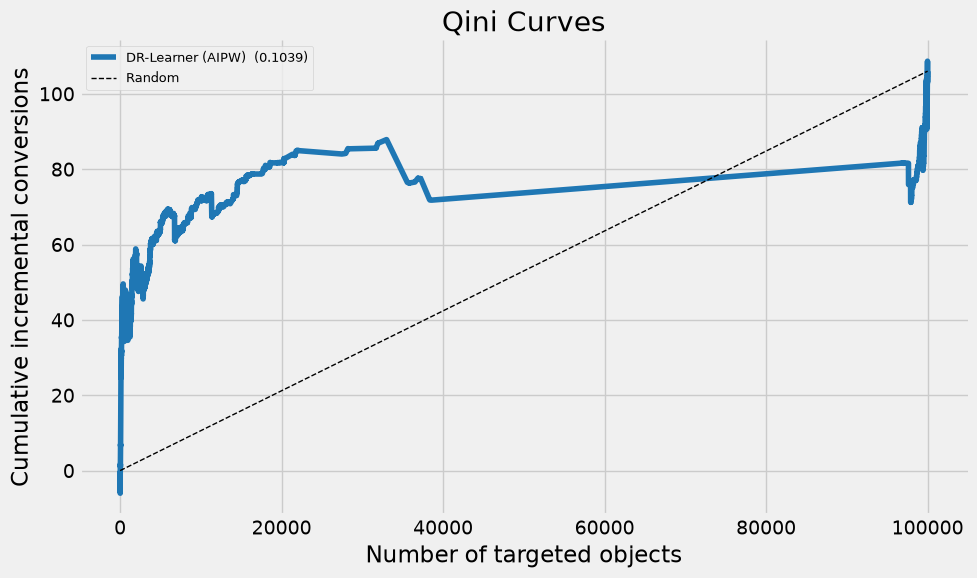

In [8]:
# Qini curves drawn by hand (see notebook 02): calling plot_qini_curve on a
# shared axis crashes on matplotlib >= 3.7.
from sklift.metrics import qini_curve
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(qini_curves)))
end = None
for (name, s), c in zip(qini_curves.items(), colors):
    x, y = qini_curve(y_test, np.asarray(s).flatten(), t_test)
    ax.plot(x, y, label=f'{name}  ({results[name]["Qini"]:.4f})', color=c)
    end = (x[-1], y[-1])
if end is not None:
    ax.plot([0, end[0]], [0, end[1]], 'k--', lw=1, label='Random')
ax.set_xlabel('Number of targeted objects')
ax.set_ylabel('Cumulative incremental conversions')
ax.set_title('Qini Curves')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.savefig(f'{ARTIFACT_NAME}_qini.png', dpi=140, bbox_inches='tight'); plt.show()

In [9]:
# Persist results for the final benchmark notebook
os.makedirs('artifacts', exist_ok=True)
with open(f'artifacts/{ARTIFACT_NAME}.pkl', 'wb') as f:
    pickle.dump({'results': results, 'qini_curves': qini_curves,
                 'y_test': y_test, 't_test': t_test}, f)
print(f"Saved artifacts/{ARTIFACT_NAME}.pkl")


Saved artifacts/04_advanced.pkl


## Summary

ITT-based methods (notebooks 01-03) answer the offer-policy question; DMLIV answers the exposure-effect question. Which is the right estimand depends on the business question, not on which model has higher Qini.

Next: [05_hpo.ipynb](05_hpo.ipynb).